# Notebook 06 — Evaluation

Purpose: Reproducible evaluation of the trained `StampClassifier` on the held-out test set. Outputs figures and a CSV summary placed under the project's outputs folders.

This notebook assumes the project `src` package and `src.config` helpers are available in `sys.path`.

## Cell 1 — Imports

In [7]:
# Use project config for portable paths
import sys
from pathlib import Path

# Ensure repo root is importable (not relying on src already on sys.path)
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import MODELS_DIR, ROI_DATASET_DIR, FIGURES_DIR, REPORTS_DIR

# Pick a model file from the models folder if exact name not known
model_candidates = sorted(MODELS_DIR.glob('*.keras'))
if len(model_candidates) == 0:
    raise FileNotFoundError(f'No .keras model files found in: {MODELS_DIR}')
MODEL_PATH = model_candidates[-1]

ROI_DATASET_ROOT = ROI_DATASET_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('MODEL_PATH =', MODEL_PATH)
print('ROI_DATASET_ROOT =', ROI_DATASET_ROOT)
print('Figures saved to =', FIGURES_DIR)
print('Reports saved to =', REPORTS_DIR)


MODEL_PATH = D:\dev\forged-stamp-recognizer\outputs\models\stamp_resnet50_final.keras
ROI_DATASET_ROOT = D:\dev\forged-stamp-recognizer\outputs\roi_dataset_v3
Figures saved to = D:\dev\forged-stamp-recognizer\outputs\figures
Reports saved to = D:\dev\forged-stamp-recognizer\outputs\reports


In [10]:
import sys
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split

from tensorflow.keras.applications.resnet50 import preprocess_input

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]
TensorFlow: 2.21.0
GPUs: []


## Cell 2 — Paths configuration

Adjust `ROI_DATASET_ROOT` and `MODEL_PATH` to match your local setup.  
If running on Google Colab, mount Drive first and update these paths accordingly.

In [12]:
# Dataset and runtime configuration
IMG_SIZE   = 224
BATCH_SIZE = 16
SEED       = 42

print('ROI dataset:', Path(ROI_DATASET_ROOT).resolve())
print('Model path: ', Path(MODEL_PATH).resolve())
print('Figures dir:', Path(FIGURES_DIR).resolve())

assert Path(ROI_DATASET_ROOT).exists(), "ROI dataset not found — run notebook 04 first."
assert Path(MODEL_PATH).exists(),       "Trained model not found — run notebook 05 first."

ROI dataset: D:\dev\forged-stamp-recognizer\outputs\roi_dataset_v3
Model path:  D:\dev\forged-stamp-recognizer\outputs\models\stamp_resnet50_final.keras
Figures dir: D:\dev\forged-stamp-recognizer\outputs\figures


## Cell 3 — Load the trained model

We load the final saved model from notebook 05. Custom metric objects must be
passed to `compile=False` when loading so Keras does not try to reconstruct them.

In [14]:
model = tf.keras.models.load_model(str(MODEL_PATH))

print("Model loaded successfully.")
print(f"Total parameters : {model.count_params():,}")
model.summary()

Model loaded successfully.
Total parameters : 23,850,113


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,275,269 (203.23 MB)

 Trainable params: 14,712,577 (56.12 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

 Optimizer params: 29,425,156 (112.25 MB)

## Cell 4 — Rebuild the test split

We recreate the **exact same test split** used in notebook 05 by using the
identical random seed and split ratios. This guarantees we evaluate on the
same held-out images the model never saw during training.

Split: **70% train / 15% val / 15% test** (stratified by class).

In [17]:
records = []
for path in (ROI_DATASET_ROOT / "genuine").rglob("*.png"):
    records.append({"image_path": str(path), "label": 0, "class_name": "genuine"})
for path in (ROI_DATASET_ROOT / "forged").rglob("*.png"):
    records.append({"image_path": str(path), "label": 1, "class_name": "forged"})

df = pd.DataFrame(records)
print(f"Total ROI images: {len(df)}")
print(df["class_name"].value_counts().to_string())

_, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
_, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

test_df = test_df.reset_index(drop=True)
print(f"\nTest set size: {len(test_df)} images")
print(test_df["class_name"].value_counts().to_string())

Total ROI images: 514
class_name
genuine    313
forged     201

Test set size: 78 images
class_name
genuine    47
forged     31


## Cell 5 — Build tf.data test pipeline

Images are resized to 224×224 and preprocessed with ResNet50's
`preprocess_input` function, which subtracts the ImageNet RGB channel means.
This is the **same preprocessing** used during training — mismatching this
would degrade inference accuracy significantly.

In [20]:
def load_and_preprocess_image(image_path, label):
    """
    tf.data map function: load PNG → resize → ResNet50 preprocessing.
    Must match the preprocessing used in notebook 05 exactly.
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)
    return image, label


test_ds = (
    tf.data.Dataset.from_tensor_slices(
        (test_df["image_path"].values, test_df["label"].values)
    )
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Test dataset pipeline built.")

Test dataset pipeline built.


## Cell 6 — Get predictions

The model outputs a single sigmoid probability per image:
- Values **≥ 0.5** → predicted **forged** (Class 1)
- Values **< 0.5** → predicted **genuine** (Class 0)

We store both the raw probabilities (`y_prob`) for threshold-based analysis
and the hard predictions (`y_pred`) for classification metrics.

In [22]:
print("Running predictions on test set...")
y_prob = model.predict(test_ds, verbose=1).ravel()
y_pred = (y_prob >= 0.40).astype(int)
y_true = test_df["label"].values

print(f"\nPredictions: {len(y_pred)} images")
print(f"Predicted genuine : {(y_pred == 0).sum()}")
print(f"Predicted forged  : {(y_pred == 1).sum()}")

Running predictions on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step  

Predictions: 78 images
Predicted genuine : 65
Predicted forged  : 13


## Cell 7 — Core metrics

### Metric definitions

| Metric | Formula | Interpretation in our context |
|---|---|---|
| **Accuracy** | (TP+TN) / Total | Overall correct classifications |
| **Precision** | TP / (TP+FP) | Of predicted forgeries, how many are actually forged? |
| **Recall** | TP / (TP+FN) | Of all actual forgeries, how many did we catch? |
| **F1-score** | 2·P·R / (P+R) | Harmonic mean — balances precision and recall |
| **ROC-AUC** | Area under ROC | Discriminative ability across all thresholds |

**In a forensic context, Recall for the forged class is most critical** —
a missed forgery (False Negative) is more harmful than a false alarm.

In [24]:
report_dict = classification_report(
    y_true, y_pred,
    target_names=["genuine", "forged"],
    output_dict=True
)
auc_score = roc_auc_score(y_true, y_prob)
ap_score  = average_precision_score(y_true, y_prob)

accuracy  = report_dict["accuracy"]
precision = report_dict["forged"]["precision"]
recall    = report_dict["forged"]["recall"]
f1        = report_dict["forged"]["f1-score"]

print("=" * 55)
print("  CLASSIFICATION METRICS — TEST SET")
print("=" * 55)
print(f"  Accuracy     : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision    : {precision:.4f}")
print(f"  Recall       : {recall:.4f}")
print(f"  F1-score     : {f1:.4f}")
print(f"  ROC-AUC      : {auc_score:.4f}")
print(f"  Avg Precision: {ap_score:.4f}")
print("=" * 55)
print()
print("Full per-class report:")
print(classification_report(y_true, y_pred, target_names=["genuine", "forged"]))

  CLASSIFICATION METRICS — TEST SET
  Accuracy     : 0.7179  (71.79%)
  Precision    : 0.8462
  Recall       : 0.3548
  F1-score     : 0.5000
  ROC-AUC      : 0.8936
  Avg Precision: 0.8152

Full per-class report:
              precision    recall  f1-score   support

     genuine       0.69      0.96      0.80        47
      forged       0.85      0.35      0.50        31

    accuracy                           0.72        78
   macro avg       0.77      0.66      0.65        78
weighted avg       0.75      0.72      0.68        78



## Cell 8 — Confusion matrix

The confusion matrix breaks down predictions into four categories:

| | Predicted genuine | Predicted forged |
|---|---|---|
| **Actual genuine** | True Negative (TN) ✓ | False Positive (FP) ✗ |
| **Actual forged** | False Negative (FN) ✗ | True Positive (TP) ✓ |

FN (missed forgeries) is the most dangerous error for document verification.

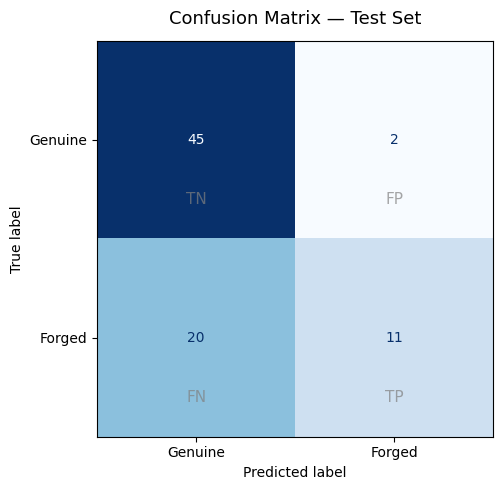

Saved: D:\dev\forged-stamp-recognizer\outputs\figures\confusion_matrix.png

TN (correct genuine): 45 | FP (genuine → forged): 2
FN (forged → genuine): 20 | TP (correct forged): 11


In [25]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Forged"]
)
disp.plot(cmap="Blues", ax=ax, colorbar=False)

# Annotate quadrant labels
quadrant_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.3, quadrant_labels[i][j],
                ha="center", va="center",
                fontsize=11, color="gray", alpha=0.7)

ax.set_title("Confusion Matrix — Test Set", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'confusion_matrix.png'}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTN (correct genuine): {tn} | FP (genuine → forged): {fp}")
print(f"FN (forged → genuine): {fn} | TP (correct forged): {tp}")

## Cell 9 — ROC curve

The **Receiver Operating Characteristic (ROC)** curve plots the True Positive Rate
against the False Positive Rate across all classification thresholds.

**AUC interpretation:**
- 1.0 = perfect separation
- 0.5 = random classifier (diagonal line)
- > 0.9 = excellent

Unlike accuracy, AUC is **threshold-independent** and robust to class imbalance.

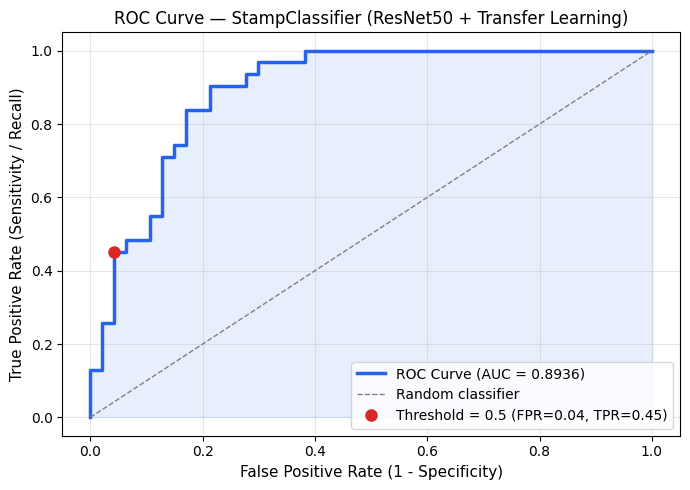

Saved: D:\dev\forged-stamp-recognizer\outputs\figures\roc_curve.png


In [27]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#2563eb", lw=2.5, label=f"ROC Curve (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Random classifier")
ax.fill_between(fpr, tpr, alpha=0.1, color="#2563eb")

# Mark operating point at threshold=0.5
idx_50 = np.argmin(np.abs(thresholds - 0.5))
ax.plot(fpr[idx_50], tpr[idx_50], "o", color="#dc2626", markersize=8,
        label=f"Threshold = 0.5 (FPR={fpr[idx_50]:.2f}, TPR={tpr[idx_50]:.2f})")

ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=11)
ax.set_title("ROC Curve — StampClassifier (ResNet50 + Transfer Learning)", fontsize=12)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'roc_curve.png'}")

## Cell 10 — Precision-Recall curve

The **Precision-Recall (PR) curve** is often more informative than the ROC curve
when the dataset is imbalanced. **Average Precision (AP)** summarises the curve as
a weighted mean of precisions at each threshold.

The baseline (dashed line) represents a classifier that randomly predicts the
positive class at the rate it appears in the dataset.

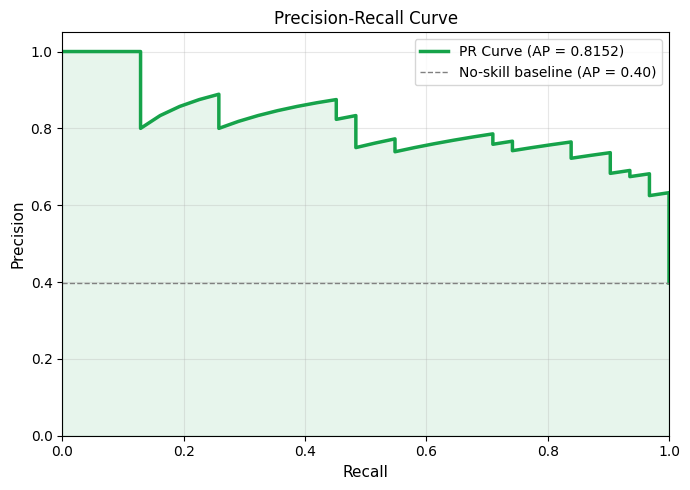

Saved: D:\dev\forged-stamp-recognizer\outputs\figures\pr_curve.png


In [29]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_true, y_prob)
baseline_ap = y_true.sum() / len(y_true)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_vals, precision_vals, color="#16a34a", lw=2.5,
        label=f"PR Curve (AP = {ap_score:.4f})")
ax.axhline(baseline_ap, color="gray", linestyle="--", lw=1,
           label=f"No-skill baseline (AP = {baseline_ap:.2f})")
ax.fill_between(recall_vals, precision_vals, alpha=0.1, color="#16a34a")

ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve", fontsize=12)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'pr_curve.png'}")

## Cell 11 — Confidence distribution

This plot shows how confident the model is about its predictions, split by
ground-truth class. A well-calibrated model should show:
- Genuine stamps peaking **near 0** (low forged probability)
- Forged stamps peaking **near 1** (high forged probability)

Overlap in the middle indicates ambiguous cases.

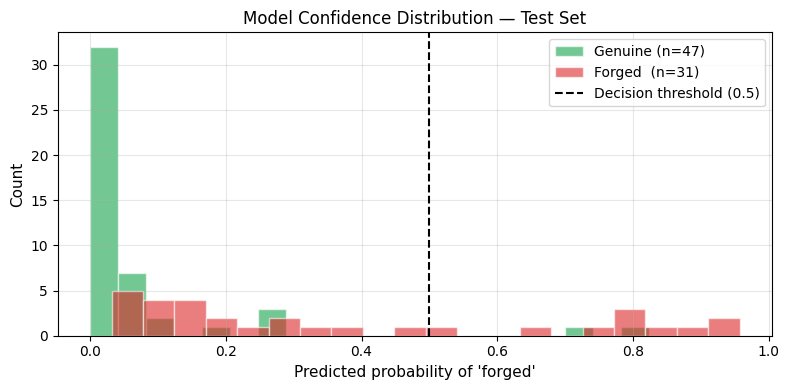

Saved: D:\dev\forged-stamp-recognizer\outputs\figures\confidence_distribution.png


In [30]:
fig, ax = plt.subplots(figsize=(8, 4))

genuine_probs = y_prob[y_true == 0]
forged_probs  = y_prob[y_true == 1]

ax.hist(genuine_probs, bins=20, alpha=0.6, color="#16a34a",
        label=f"Genuine (n={len(genuine_probs)})", edgecolor="white")
ax.hist(forged_probs, bins=20, alpha=0.6, color="#dc2626",
        label=f"Forged  (n={len(forged_probs)})", edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", lw=1.5, label="Decision threshold (0.5)")

ax.set_xlabel("Predicted probability of 'forged'", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Model Confidence Distribution — Test Set", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'confidence_distribution.png'}")

## Cell 12 — Misclassification gallery

Visually inspecting misclassified samples provides forensic insight:

- **False Positives (genuine → predicted forged):** often faded, noisy, or
  heavily overlapped genuine stamps whose ink texture resembles halftone printing.
- **False Negatives (forged → predicted genuine):** high-quality forgeries that
  the model couldn't distinguish — these represent the hardest attack cases.

Understanding these failures guides improvements to the dataset and pipeline.

Total misclassified: 22 / 78 (28.2%)
  False Positives (genuine → forged): 2
  False Negatives (forged → genuine): 20


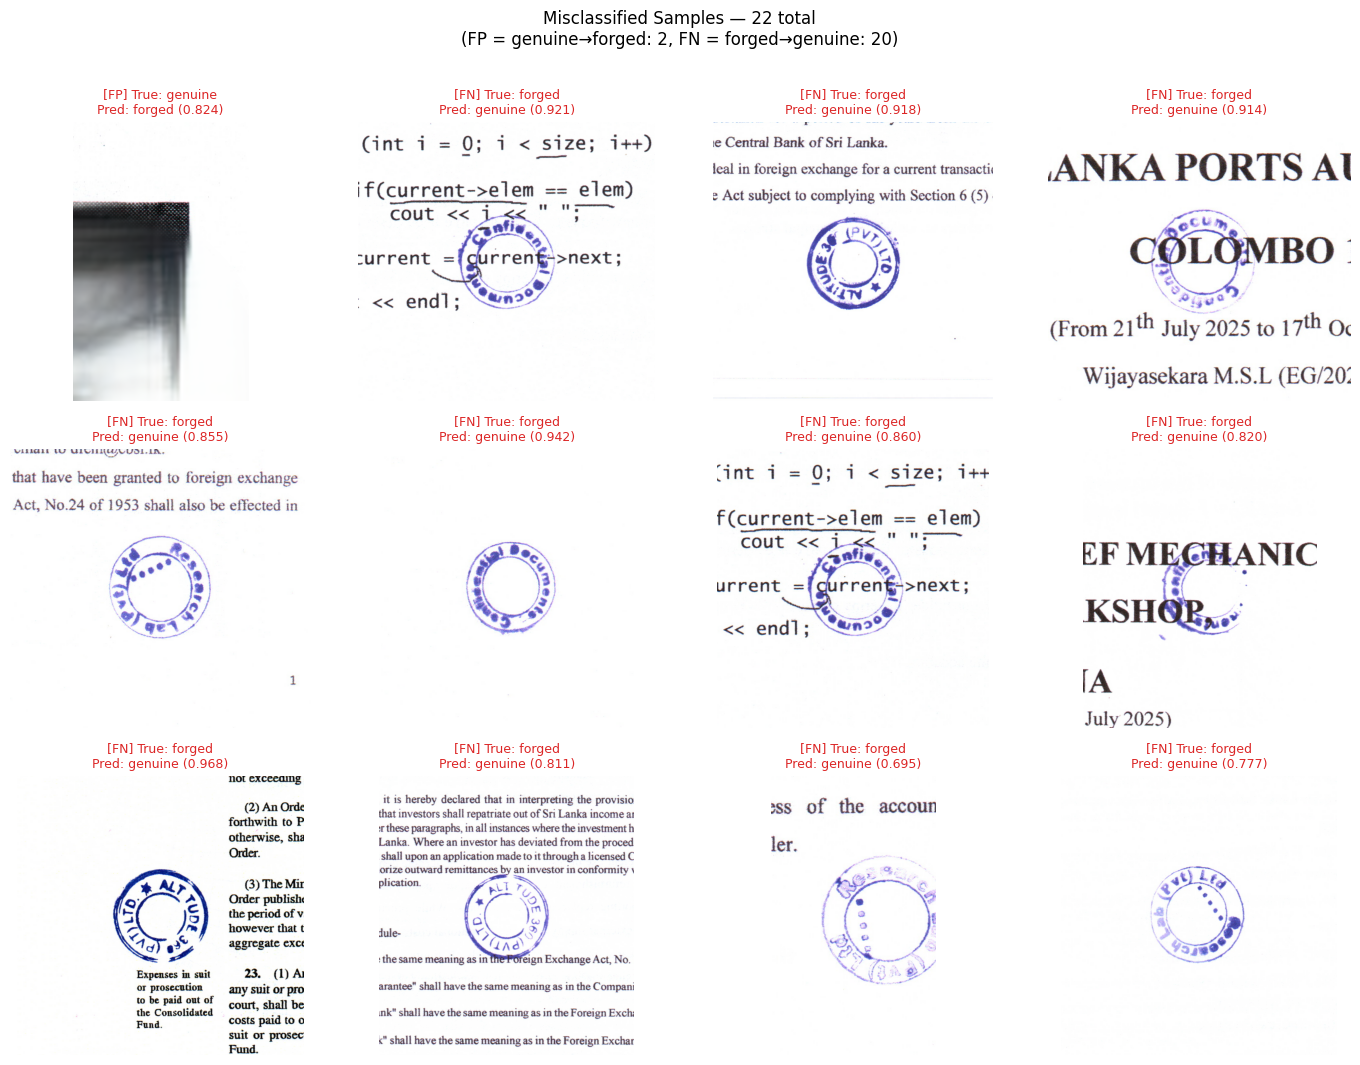

Saved: D:\dev\forged-stamp-recognizer\outputs\figures\misclassified_gallery.png


In [31]:
CLASS_NAMES = {0: "genuine", 1: "forged"}

errors = np.where(y_true != y_pred)[0]
print(f"Total misclassified: {len(errors)} / {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)")

fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]  # Genuine → predicted forged
fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]  # Forged → predicted genuine

print(f"  False Positives (genuine → forged): {len(fp_idx)}")
print(f"  False Negatives (forged → genuine): {len(fn_idx)}")

if len(errors) == 0:
    print("Perfect test accuracy — no misclassified samples to display.")
else:
    n = min(12, len(errors))
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5 * rows))
    axes = np.array(axes).flatten()

    for idx, err_idx in enumerate(errors[:n]):
        path = test_df["image_path"].values[err_idx]
        img  = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        true_label = CLASS_NAMES[y_true[err_idx]]
        pred_label = CLASS_NAMES[y_pred[err_idx]]
        conf = y_prob[err_idx] if y_pred[err_idx] == 1 else 1.0 - y_prob[err_idx]
        error_type = "FP" if (y_true[err_idx] == 0) else "FN"

        axes[idx].imshow(img)
        axes[idx].set_title(
            f"[{error_type}] True: {true_label}\nPred: {pred_label} ({conf:.3f})",
            fontsize=9, color="#dc2626"
        )
        axes[idx].axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.suptitle(
        f"Misclassified Samples — {len(errors)} total\n"
        f"(FP = genuine→forged: {len(fp_idx)}, FN = forged→genuine: {len(fn_idx)})",
        fontsize=12, y=1.01
    )
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "misclassified_gallery.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {FIGURES_DIR / 'misclassified_gallery.png'}")

## Cell 13 — Inference speed measurement

Inference speed is a key practical metric. We measure how many milliseconds
the full model takes to process a **single image** on CPU (representative of
a production deployment without GPU).

The first call is a **warm-up** (excluded from statistics) to account for TensorFlow
graph tracing overhead.

Inference speed over 30 images (CPU):
  Mean   : 158.2 ms
  Std    : 20.5 ms
  Median : 151.3 ms
  Min    : 144.0 ms
  Max    : 233.4 ms
  Throughput ≈ 6.3 images/second


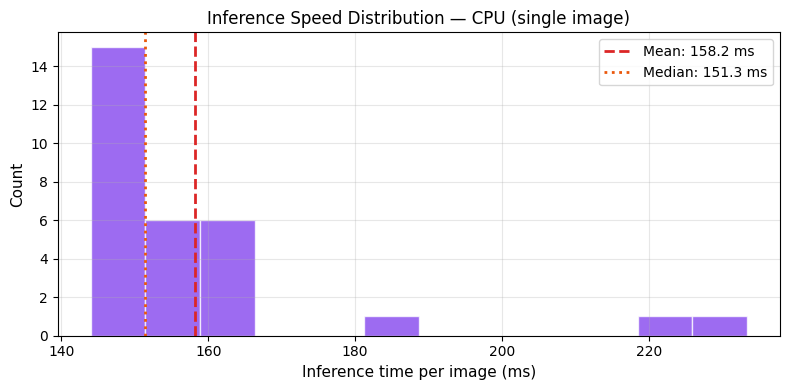

Saved: D:\dev\forged-stamp-recognizer\outputs\figures\inference_speed.png


In [34]:
def load_single_image(path: str, img_size: int = 224) -> np.ndarray:
    """Load, resize, and preprocess a single image for inference."""
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    from tensorflow.keras.applications.resnet50 import preprocess_input
    img = preprocess_input(img.astype(np.float32))
    return np.expand_dims(img, axis=0)


image_paths = test_df["image_path"].values
N_RUNS = min(30, len(image_paths))

# Warm-up
_ = model.predict(load_single_image(image_paths[0]), verbose=0)

# Timed runs
times_ms = []
for path in image_paths[:N_RUNS]:
    img = load_single_image(path)
    t0  = time.perf_counter()
    _   = model.predict(img, verbose=0)
    t1  = time.perf_counter()
    times_ms.append((t1 - t0) * 1000)

print(f"Inference speed over {N_RUNS} images (CPU):")
print(f"  Mean   : {np.mean(times_ms):.1f} ms")
print(f"  Std    : {np.std(times_ms):.1f} ms")
print(f"  Median : {np.median(times_ms):.1f} ms")
print(f"  Min    : {np.min(times_ms):.1f} ms")
print(f"  Max    : {np.max(times_ms):.1f} ms")
print(f"  Throughput ≈ {1000/np.mean(times_ms):.1f} images/second")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(times_ms, bins=12, color="#7c3aed", alpha=0.75, edgecolor="white")
ax.axvline(np.mean(times_ms), color="#dc2626", linestyle="--", lw=2,
           label=f"Mean: {np.mean(times_ms):.1f} ms")
ax.axvline(np.median(times_ms), color="#ea580c", linestyle=":", lw=2,
           label=f"Median: {np.median(times_ms):.1f} ms")
ax.set_xlabel("Inference time per image (ms)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Inference Speed Distribution — CPU (single image)", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "inference_speed.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'inference_speed.png'}")

## Cell 14 — Grad-CAM explainability

**Gradient-weighted Class Activation Mapping (Grad-CAM)** highlights spatial regions the model used for its decision.

**Why this matters:**
- Verifies the model focuses on ink texture inside the stamp ROI rather than unrelated document features.
- Heatmaps concentrated on the stamp confirm the ROI extraction and model alignment.

**Method:** Compute gradients of the model's output with respect to a late convolutional layer (e.g. `conv5_block3_out` in ResNet50).

In [35]:
from tensorflow.keras.applications import ResNet50

def get_grad_cam(model, image_array, layer_name="conv5_block3_out"):

    # 1. Find ResNet sub-model
    resnet_submodel = None
    for layer in model.layers:
        if "resnet" in layer.name.lower():
            resnet_submodel = layer
            break
    if resnet_submodel is None:
        print("Warning: ResNet submodel not found.")
        return np.zeros((7, 7))

    # 2. Standalone ResNet with copied weights
    standalone = ResNet50(weights=None, include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    standalone.set_weights(resnet_submodel.get_weights())

    # 3. Target conv layer
    try:
        target_layer = standalone.get_layer(layer_name)
    except ValueError:
        for l in reversed(standalone.layers):
            if len(l.output_shape) == 4:
                target_layer = l
                print(f"Fallback layer: '{l.name}'")
                break

    # 4. Collect head layers (everything after resnet in outer model)
    head_layers = []
    found_resnet = False
    for layer in model.layers:
        if "resnet" in layer.name.lower():
            found_resnet = True
            continue
        if found_resnet:
            head_layers.append(layer)

    # 5. Build ONE end-to-end model: input → conv_out branch + sigmoid branch
    inp      = standalone.input
    conv_out = target_layer.output
    x        = standalone.output
    for layer in head_layers:
        x = layer(x)

    grad_model = tf.keras.models.Model(inputs=inp, outputs=[conv_out, x])

    # 6. Single forward pass — loss and conv_outputs in the SAME graph
    img_tensor = tf.cast(image_array, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, pred = grad_model(img_tensor, training=False)
        loss = pred[:, 0]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_grad_cam(original_bgr, heatmap, alpha=0.4):
    h, w            = original_bgr.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    overlaid        = cv2.addWeighted(original_bgr, 1-alpha, heatmap_color, alpha, 0)
    return overlaid

print("Grad-CAM functions defined.")

Grad-CAM functions defined.


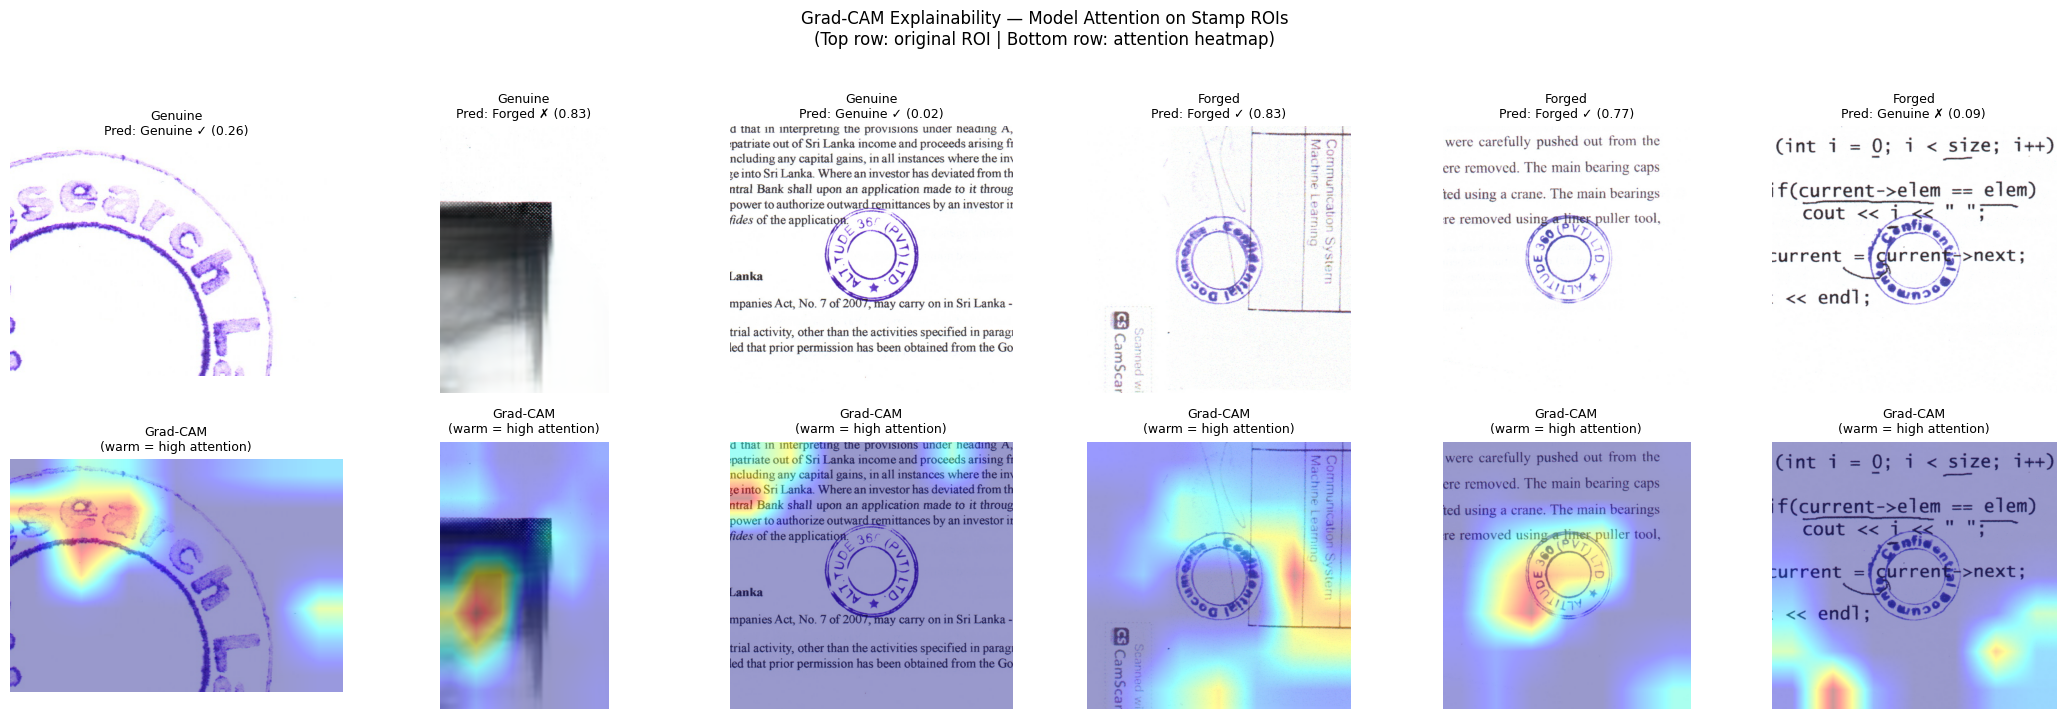

Saved: D:\dev\forged-stamp-recognizer\outputs\figures\gradcam_gallery.png


In [28]:
# ── Select samples for Grad-CAM gallery ─────────────────────────────────────
N_GENUINE = 3
N_FORGED  = 3

genuine_sample_paths = test_df[test_df["label"] == 0]["image_path"].values[:N_GENUINE]
forged_sample_paths  = test_df[test_df["label"] == 1]["image_path"].values[:N_FORGED]
all_paths = list(genuine_sample_paths) + list(forged_sample_paths)
all_labels = ["Genuine"] * N_GENUINE + ["Forged"] * N_FORGED

total = len(all_paths)
fig, axes = plt.subplots(2, total, figsize=(3.5 * total, 7))

for col, (path, label) in enumerate(zip(all_paths, all_labels)):
    # Load original
    original_bgr = cv2.imread(path)
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)

    # Compute Grad-CAM
    img_array = load_single_image(path)
    heatmap   = get_grad_cam(model, img_array)
    cam_bgr   = overlay_grad_cam(original_bgr, heatmap)
    cam_rgb   = cv2.cvtColor(cam_bgr, cv2.COLOR_BGR2RGB)

    # Get model's prediction on this image
    prob = float(model.predict(img_array, verbose=0)[0, 0])
    pred_label = "Forged" if prob >= 0.40 else "Genuine"
    correct = "✓" if pred_label == label else "✗"

    axes[0, col].imshow(original_rgb)
    axes[0, col].set_title(f"{label}\nPred: {pred_label} {correct} ({prob:.2f})",
                           fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(cam_rgb)
    axes[1, col].set_title("Grad-CAM\n(warm = high attention)", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle(
    "Grad-CAM Explainability — Model Attention on Stamp ROIs\n"
    "(Top row: original ROI | Bottom row: attention heatmap)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gradcam_gallery.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR / 'gradcam_gallery.png'}")

## Cell 15 — Final metrics summary table

All metrics collected into a single summary table and saved as CSV for
inclusion in the project report.

In [36]:
summary = {
    "Model"            : "ResNet50 (Transfer Learning + Fine-Tuning)",
    "Test set size"    : len(test_df),
    "Accuracy"         : f"{accuracy:.4f}",
    "Precision"        : f"{precision:.4f}",
    "Recall"           : f"{recall:.4f}",
    "F1-score"         : f"{f1:.4f}",
    "ROC-AUC"          : f"{auc_score:.4f}",
    "Average Precision": f"{ap_score:.4f}",
    "True Positives"   : int(tp),
    "True Negatives"   : int(tn),
    "False Positives"  : int(fp),
    "False Negatives"  : int(fn),
    "Inference mean ms": f"{np.mean(times_ms):.1f}",
    "Inference std ms" : f"{np.std(times_ms):.1f}",
    "Throughput img/s" : f"{1000/np.mean(times_ms):.1f}",
}

df_summary = pd.DataFrame([summary]).T.rename(columns={0: "Value"})

print("\n" + "=" * 50)
print("  FINAL METRICS SUMMARY")
print("=" * 50)
print(df_summary.to_string())

csv_path = REPORTS_DIR / "metrics_summary.csv"
df_summary.to_csv(csv_path)
print(f"\nSaved: {csv_path}")


  FINAL METRICS SUMMARY
                                                        Value
Model              ResNet50 (Transfer Learning + Fine-Tuning)
Test set size                                              78
Accuracy                                               0.7179
Precision                                              0.8462
Recall                                                 0.3548
F1-score                                               0.5000
ROC-AUC                                                0.8936
Average Precision                                      0.8152
True Positives                                             11
True Negatives                                             45
False Positives                                             2
False Negatives                                            20
Inference mean ms                                       158.2
Inference std ms                                         20.5
Throughput img/s                             

## Cell 16 — Summary of all saved outputs

In [37]:
print("\nAll outputs saved:")
print()
all_outputs = [
    (FIGURES_DIR / "confusion_matrix.png",      "Confusion matrix"),
    (FIGURES_DIR / "roc_curve.png",             "ROC curve + AUC"),
    (FIGURES_DIR / "pr_curve.png",              "Precision-Recall curve"),
    (FIGURES_DIR / "confidence_distribution.png","Confidence score distribution"),
    (FIGURES_DIR / "misclassified_gallery.png", "Misclassified sample gallery"),
    (FIGURES_DIR / "inference_speed.png",       "Inference speed distribution"),
    (FIGURES_DIR / "gradcam_gallery.png",       "Grad-CAM explainability gallery"),
    (REPORTS_DIR / "metrics_summary.csv",       "Metrics summary CSV"),
]

for path, desc in all_outputs:
    exists = "✓" if path.exists() else "✗ NOT FOUND"
    print(f"  {exists}  {desc:40s}  {path.name}")


All outputs saved:

  ✓  Confusion matrix                          confusion_matrix.png
  ✓  ROC curve + AUC                           roc_curve.png
  ✓  Precision-Recall curve                    pr_curve.png
  ✓  Confidence score distribution             confidence_distribution.png
  ✓  Misclassified sample gallery              misclassified_gallery.png
  ✓  Inference speed distribution              inference_speed.png
  ✓  Grad-CAM explainability gallery           gradcam_gallery.png
  ✓  Metrics summary CSV                       metrics_summary.csv
